
=== RESULTADOS ===
                                                                        0
Fmax_nN                                                        124.557261
indentation_max_nm                                              96.936568
contact_point_index                                                    74
z_cp_nm                                                         99.885712
baseline_noise_nN                                                 0.02075
contact_threshold_nN                                             0.103748
k_0_10nm_N_per_m                                                 0.002148
r2_0_10nm                                                             1.0
n_0_10nm                                                               10
k_10_20nm_N_per_m                                                0.013146
r2_10_20nm                                                       0.809326
n_10_20nm                                                               9
k_20_40nm_N_per_m 

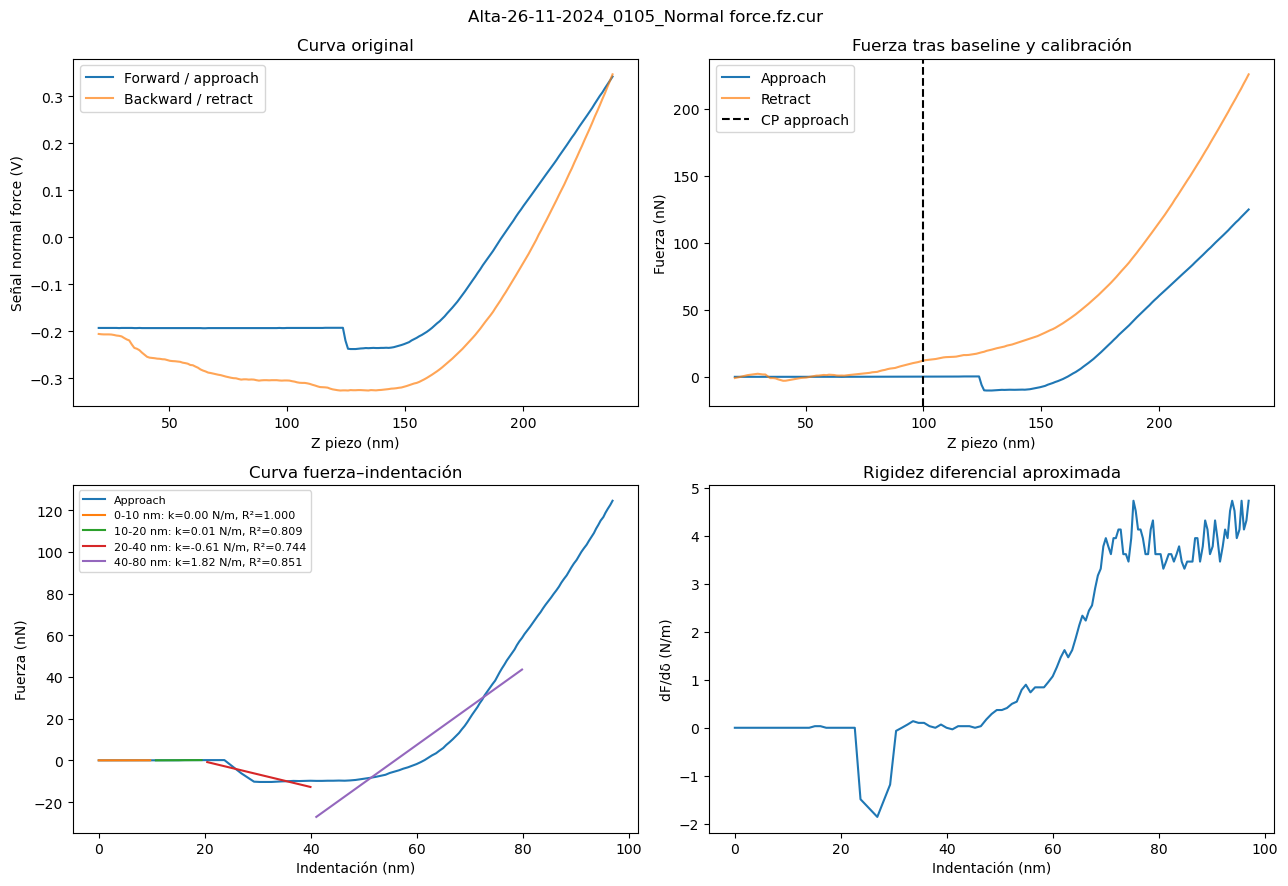

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress


# ============================================================
# CONFIGURACIÓN MANUAL
# ============================================================

FILE_PATH = r"C:\Users\david\Desktop\Python Bacterias\Curvas Pruebas\Nuevo\Alta-26-11-2024_0105_Normal force.fz.cur"

# Constante del cantiléver.
# OJO: 1 N/m = 1 nN/nm
CANTILEVER_K_N_PER_M = 3.02

# Sensibilidad de deflexión obtenida sobre SiO2.
# Unidad: nm/V
DEFLECTION_SENSITIVITY_NM_PER_V = 77.0

# Fracción inicial usada como baseline no-contacto.
# 0.20 significa usar el primer 20 % de la curva.
BASELINE_FRACTION = 0.20

# Umbral para detectar contacto: múltiplos del ruido del baseline.
CONTACT_SIGMA_THRESHOLD = 5.0

# Número mínimo de puntos consecutivos por encima del umbral
# para aceptar el punto de contacto.
MIN_CONSECUTIVE_CONTACT_POINTS = 4

# Rangos de indentación donde calcular rigidez local.
# Unidad: nm
STIFFNESS_RANGES_NM = [
    (0, 10),
    (10, 20),
    (20, 40),
    (40, 80)
]

# Mostrar gráficas
PLOT = True


# ============================================================
# FUNCIONES BÁSICAS
# ============================================================

def read_wsxm_cur(file_path):
    """
    Lee un archivo .cur de WSxM con 4 columnas:
    Z_forward, V_forward, Z_backward, V_backward.
    """
    file_path = Path(file_path)

    with open(file_path, "r", errors="ignore") as f:
        lines = f.readlines()

    header_end = None
    for i, line in enumerate(lines):
        if line.strip() == "[Header end]":
            header_end = i
            break

    if header_end is None:
        raise ValueError("No se encontró '[Header end]' en el archivo.")

    data = []
    for line in lines[header_end + 1:]:
        if line.strip() and not line.strip().startswith("["):
            parts = line.split()
            if len(parts) >= 4:
                data.append([float(x) for x in parts[:4]])

    data = np.array(data)

    if data.shape[1] < 4:
        raise ValueError("El archivo no tiene 4 columnas numéricas.")

    df = pd.DataFrame({
        "z_forward_nm": data[:, 0],
        "v_forward_V": data[:, 1],
        "z_backward_nm": data[:, 2],
        "v_backward_V": data[:, 3],
    })

    return df


def linear_baseline_correction(z_nm, v_V, baseline_fraction=0.20):
    """
    Corrige baseline ajustando una recta al tramo inicial de no contacto.
    Devuelve señal corregida y parámetros del ajuste.
    """
    n = len(z_nm)
    n_base = max(10, int(n * baseline_fraction))

    z_base = z_nm[:n_base]
    v_base = v_V[:n_base]

    slope, intercept, r_value, p_value, std_err = linregress(z_base, v_base)

    baseline = slope * z_nm + intercept
    v_corr = v_V - baseline

    return v_corr, {
        "baseline_slope_V_per_nm": slope,
        "baseline_intercept_V": intercept,
        "baseline_r2": r_value**2,
        "baseline_points": n_base
    }


def force_sign_correction(v_corr):
    """
    Hace que la fuerza repulsiva de contacto sea positiva.
    Si el tramo final está por debajo del inicial, invierte el signo.
    """
    n = len(v_corr)
    start_med = np.median(v_corr[:max(5, n // 10)])
    end_med = np.median(v_corr[-max(5, n // 10):])

    sign = 1.0
    if end_med < start_med:
        sign = -1.0

    return v_corr * sign, sign


def detect_contact_point(force_nN, baseline_points, sigma_threshold=5.0,
                         min_consecutive=4):
    """
    Detecta el punto de contacto usando umbral sobre el ruido del baseline.
    Busca el primer tramo con varios puntos consecutivos por encima del umbral.
    """
    baseline_force = force_nN[:baseline_points]
    noise = np.std(baseline_force)
    threshold = sigma_threshold * noise

    if threshold == 0:
        threshold = np.std(force_nN) * 0.01

    above = force_nN > threshold

    for i in range(baseline_points, len(force_nN) - min_consecutive):
        if np.all(above[i:i + min_consecutive]):
            return i, threshold, noise

    # Si no encuentra contacto, usa el punto de mayor cambio de pendiente.
    derivative = np.gradient(force_nN)
    search_region = derivative[baseline_points:]
    cp_index = baseline_points + np.argmax(search_region)

    return cp_index, threshold, noise


def convert_to_force_indentation(z_nm, v_V, sensitivity_nm_per_V,
                                 cantilever_k_N_per_m,
                                 baseline_fraction=0.20,
                                 sigma_threshold=5.0):
    """
    Convierte una rama Z/V en fuerza-indentación:
    V -> deflexión nm -> fuerza nN -> indentación nm.
    """
    v_corr, baseline_info = linear_baseline_correction(
        z_nm, v_V, baseline_fraction=baseline_fraction
    )

    v_corr, sign = force_sign_correction(v_corr)

    deflection_nm = v_corr * sensitivity_nm_per_V

    # 1 N/m = 1 nN/nm
    cantilever_k_nN_per_nm = cantilever_k_N_per_m

    force_nN = deflection_nm * cantilever_k_nN_per_nm

    cp_index, contact_threshold_nN, baseline_noise_nN = detect_contact_point(
        force_nN,
        baseline_points=baseline_info["baseline_points"],
        sigma_threshold=sigma_threshold
    )

    z_cp = z_nm[cp_index]
    defl_cp = deflection_nm[cp_index]
    force_cp = force_nN[cp_index]

    z_contact = z_nm[cp_index:]
    defl_contact = deflection_nm[cp_index:]
    force_contact = force_nN[cp_index:] - force_cp

    indentation_nm = (z_contact - z_cp) - (defl_contact - defl_cp)

    # Nos quedamos con indentaciones positivas y fuerzas positivas.
    valid = (indentation_nm >= 0)

    indentation_nm = indentation_nm[valid]
    force_contact = force_contact[valid]

    result = {
        "z_nm": z_nm,
        "v_raw_V": v_V,
        "v_corr_V": v_corr,
        "deflection_nm": deflection_nm,
        "force_nN": force_nN,
        "cp_index": cp_index,
        "z_cp_nm": z_cp,
        "force_cp_nN": force_cp,
        "indentation_nm": indentation_nm,
        "force_contact_nN": force_contact,
        "contact_threshold_nN": contact_threshold_nN,
        "baseline_noise_nN": baseline_noise_nN,
        "sign_correction": sign,
        **baseline_info
    }

    return result


def fit_stiffness_in_range(indentation_nm, force_nN, range_nm):
    """
    Ajusta F = k*indentation + b en un rango de indentación.
    Devuelve k en N/m, equivalente a nN/nm.
    """
    low, high = range_nm
    mask = (indentation_nm >= low) & (indentation_nm <= high)

    if np.sum(mask) < 5:
        return {
            "range_nm": range_nm,
            "k_N_per_m": np.nan,
            "intercept_nN": np.nan,
            "r2": np.nan,
            "n_points": int(np.sum(mask))
        }

    x = indentation_nm[mask]
    y = force_nN[mask]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    return {
        "range_nm": range_nm,
        "k_N_per_m": slope,
        "intercept_nN": intercept,
        "r2": r_value**2,
        "n_points": int(np.sum(mask))
    }


def summarize_curve(approach_result, stiffness_ranges_nm):
    """
    Extrae parámetros principales de la curva de aproximación.
    """
    indentation = approach_result["indentation_nm"]
    force = approach_result["force_contact_nN"]

    summary = {
        "Fmax_nN": np.nanmax(force) if len(force) else np.nan,
        "indentation_max_nm": np.nanmax(indentation) if len(indentation) else np.nan,
        "contact_point_index": approach_result["cp_index"],
        "z_cp_nm": approach_result["z_cp_nm"],
        "baseline_noise_nN": approach_result["baseline_noise_nN"],
        "contact_threshold_nN": approach_result["contact_threshold_nN"]
    }

    for low, high in stiffness_ranges_nm:
        fit = fit_stiffness_in_range(indentation, force, (low, high))
        label = f"{low}_{high}nm"
        summary[f"k_{label}_N_per_m"] = fit["k_N_per_m"]
        summary[f"r2_{label}"] = fit["r2"]
        summary[f"n_{label}"] = fit["n_points"]

    return summary


def estimate_adhesion_from_retract(retract_result):
    """
    Estimación preliminar de adhesión:
    valor mínimo de fuerza tras corrección de baseline.
    Si hay valores negativos fuertes, indica pull-off/adhesión.
    """
    force = retract_result["force_nN"]
    f_min = np.nanmin(force)
    return {
        "Fadh_min_nN": f_min,
        "Fadh_abs_nN": abs(f_min) if f_min < 0 else 0.0
    }


def plot_diagnostics(df, approach, retract, summary, file_path):
    """
    Gráficas diagnósticas principales.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # Curva original
    axes[0, 0].plot(df["z_forward_nm"], df["v_forward_V"], label="Forward / approach")
    axes[0, 0].plot(df["z_backward_nm"], df["v_backward_V"], label="Backward / retract", alpha=0.7)
    axes[0, 0].set_xlabel("Z piezo (nm)")
    axes[0, 0].set_ylabel("Señal normal force (V)")
    axes[0, 0].set_title("Curva original")
    axes[0, 0].legend()

    # Curva corregida en fuerza
    axes[0, 1].plot(approach["z_nm"], approach["force_nN"], label="Approach")
    axes[0, 1].plot(retract["z_nm"], retract["force_nN"], label="Retract", alpha=0.7)
    axes[0, 1].axvline(approach["z_cp_nm"], color="k", linestyle="--", label="CP approach")
    axes[0, 1].set_xlabel("Z piezo (nm)")
    axes[0, 1].set_ylabel("Fuerza (nN)")
    axes[0, 1].set_title("Fuerza tras baseline y calibración")
    axes[0, 1].legend()

    # Fuerza-indentación approach
    axes[1, 0].plot(approach["indentation_nm"], approach["force_contact_nN"], label="Approach")
    axes[1, 0].set_xlabel("Indentación (nm)")
    axes[1, 0].set_ylabel("Fuerza (nN)")
    axes[1, 0].set_title("Curva fuerza–indentación")

    # Añadir ajustes lineales por rangos
    for low, high in STIFFNESS_RANGES_NM:
        k = summary.get(f"k_{low}_{high}nm_N_per_m", np.nan)
        r2 = summary.get(f"r2_{low}_{high}nm", np.nan)

        if not np.isnan(k):
            mask = (
                (approach["indentation_nm"] >= low) &
                (approach["indentation_nm"] <= high)
            )
            x = approach["indentation_nm"][mask]
            y = approach["force_contact_nN"][mask]
            if len(x) >= 5:
                slope, intercept, *_ = linregress(x, y)
                axes[1, 0].plot(x, slope * x + intercept,
                                label=f"{low}-{high} nm: k={k:.2f} N/m, R²={r2:.3f}")

    axes[1, 0].legend(fontsize=8)

    # Rigidez diferencial aproximada
    if len(approach["indentation_nm"]) > 10:
        dF = np.gradient(approach["force_contact_nN"])
        ddelta = np.gradient(approach["indentation_nm"])
        k_diff = dF / ddelta

        axes[1, 1].plot(approach["indentation_nm"], k_diff)
        axes[1, 1].set_xlabel("Indentación (nm)")
        axes[1, 1].set_ylabel("dF/dδ (N/m)")
        axes[1, 1].set_title("Rigidez diferencial aproximada")

    fig.suptitle(Path(file_path).name)
    plt.tight_layout()
    plt.show()


# ============================================================
# EJECUCIÓN
# ============================================================

df = read_wsxm_cur(FILE_PATH)

approach = convert_to_force_indentation(
    z_nm=df["z_forward_nm"].values,
    v_V=df["v_forward_V"].values,
    sensitivity_nm_per_V=DEFLECTION_SENSITIVITY_NM_PER_V,
    cantilever_k_N_per_m=CANTILEVER_K_N_PER_M,
    baseline_fraction=BASELINE_FRACTION,
    sigma_threshold=CONTACT_SIGMA_THRESHOLD
)

retract = convert_to_force_indentation(
    z_nm=df["z_backward_nm"].values,
    v_V=df["v_backward_V"].values,
    sensitivity_nm_per_V=DEFLECTION_SENSITIVITY_NM_PER_V,
    cantilever_k_N_per_m=CANTILEVER_K_N_PER_M,
    baseline_fraction=BASELINE_FRACTION,
    sigma_threshold=CONTACT_SIGMA_THRESHOLD
)

summary = summarize_curve(approach, STIFFNESS_RANGES_NM)
adhesion = estimate_adhesion_from_retract(retract)

summary.update(adhesion)
summary["file"] = Path(FILE_PATH).name
summary["cantilever_k_N_per_m"] = CANTILEVER_K_N_PER_M
summary["deflection_sensitivity_nm_per_V"] = DEFLECTION_SENSITIVITY_NM_PER_V

results = pd.DataFrame([summary])

print("\n=== RESULTADOS ===")
print(results.T)

if PLOT:
    plot_diagnostics(df, approach, retract, summary, FILE_PATH)